In [ ]:
# =================================================================
# 1. PREPARAÇÃO (Execução Silenciosa)
# =================================================================
!pip install -q "numpy<2" "scikit-fuzzy" "google-genai" matplotlib ipywidgets

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from google import genai
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
from IPython.display import display, clear_output

# Configura o Matplotlib para renderização rápida
%matplotlib inline

# =================================================================
# 2. LÓGICA FUZZY (Motor de Decisão)
# =================================================================
distancia = ctrl.Antecedent(np.arange(0, 51, 1), 'distancia')
velocidade = ctrl.Antecedent(np.arange(0, 6, 1), 'velocidade')
prioridade = ctrl.Antecedent(np.arange(1, 11, 1), 'prioridade')
urgencia = ctrl.Consequent(np.arange(0, 101, 1), 'urgencia')

distancia.automf(3, names=['perto', 'media', 'longe'])
velocidade.automf(2, names=['baixa', 'alta'])
prioridade.automf(2, names=['baixa', 'alta'])
urgencia.automf(3, names=['baixa', 'media', 'alta'])

# Regras de Cobertura Universal (Evita erro de chave)
regras = [
    ctrl.Rule(distancia['perto'] | velocidade['alta'], urgencia['alta']),
    ctrl.Rule(distancia['media'] & prioridade['alta'], urgencia['alta']),
    ctrl.Rule(distancia['media'] & prioridade['baixa'], urgencia['media']),
    ctrl.Rule(distancia['longe'] & velocidade['baixa'], urgencia['baixa']),
    ctrl.Rule(prioridade['alta'] & velocidade['alta'], urgencia['alta']),
    ctrl.Rule(distancia['longe'] & prioridade['baixa'], urgencia['baixa'])
]

simulador = ctrl.ControlSystemSimulation(ctrl.ControlSystem(regras))

# Malha 3D Otimizada (15x15 para resposta instantânea)
x_range = np.linspace(0, 50, 15)
y_range = np.linspace(0, 5, 15)
x_mesh, y_mesh = np.meshgrid(x_range, y_range)
cache_z = {'last_prio': -1, 'z_mesh': None}

# =================================================================
# 3. DASHBOARD INTERATIVO DE ALTA PERFORMANCE
# =================================================================
# Sliders configurados para não gerar lag
dist_slider = widgets.IntSlider(value=15, min=0, max=50, description='Distância (m)', continuous_update=False)
vel_slider = widgets.FloatSlider(value=4.0, min=0, max=5, step=0.1, description='Velocidade (m/s)', continuous_update=False)
prio_slider = widgets.IntSlider(value=9, min=1, max=10, description='Prioridade', continuous_update=False)

btn_ia = widgets.Button(description='Gerar Relatório IA', button_style='primary', icon='rocket')
out_visual = widgets.Output()
out_txt = widgets.Output()

def renderizar_dashboard(dist, vel, prio):
    global cache_z
    with out_visual:
        clear_output(wait=True)

        # OTIMIZAÇÃO: Recalcula a superfície apenas se a prioridade mudar
        if cache_z['last_prio'] != prio:
            z_mesh = np.zeros_like(x_mesh)
            for i in range(15):
                for j in range(15):
                    simulador.input['distancia'] = x_mesh[i, j]
                    simulador.input['velocidade'] = y_mesh[i, j]
                    simulador.input['prioridade'] = prio
                    simulador.compute()
                    z_mesh[i, j] = simulador.output['urgencia']
            cache_z['z_mesh'] = z_mesh
            cache_z['last_prio'] = prio

        # Cálculo rápido do ponto atual
        simulador.input['distancia'] = dist
        simulador.input['velocidade'] = vel
        simulador.input['prioridade'] = prio
        simulador.compute()
        res = simulador.output['urgencia']

        # Visualização Profissional
        fig = plt.figure(figsize=(14, 5))
        plt.style.use('seaborn-v0_8-whitegrid')

        # 3D Plot
        ax1 = fig.add_subplot(1, 2, 1, projection='3d')
        ax1.plot_surface(x_mesh, y_mesh, cache_z['z_mesh'], cmap='plasma', alpha=0.7)
        ax1.scatter(dist, vel, res, color='black', s=150, marker='*', label='AGV')
        ax1.set_title("Estratégia de Controle 3D")
        ax1.view_init(25, 215)

        # Gauge Plot
        ax2 = fig.add_subplot(1, 2, 2)
        status_color = '#2ecc71' if res < 40 else ('#f1c40f' if res < 70 else '#e74c3c')
        ax2.barh(['URGÊNCIA'], [100], color='#ecf0f1')
        ax2.barh(['URGÊNCIA'], [res], color=status_color)
        ax2.set_xlim(0, 100)
        ax2.set_title(f"Status: {res:.1f}%")

        plt.tight_layout()
        plt.show()

def solicitar_ia(b):
    with out_txt:
        clear_output()
        print("⚡ Analisando telemetria e gerando relatório profundo...")
        CHAVE_API =  "SUA_CHAVE_AQUI"
        client = genai.Client(api_key=CHAVE_API)
        res = simulador.output['urgencia']

        prompt = f"""
        Como Engenheiro de Automação e Manutenção, analise: AGV a {dist_slider.value}m, {vel_slider.value}m/s, prioridade {prio_slider.value}.
        Urgência: {res:.2f}%.
        Gere um relatório técnico sobre:
        1. Risco de impacto cinético.
        2. Desgaste de atuadores e freios.
        3. Plano de manutenção preditiva sugerido.
        4. Uma explicação em linguagem natural sobre o porquê daquela decisão.
        5. Sugestões de ajustes ou alertas estratégicos baseados no contexto do problema.
        """
        try:
            r = client.models.generate_content(model='gemini-2.5-flash', contents=prompt)
            print("\n" + "═"*75 + "\n" + r.text + "\n" + "═"*75)
        except: print("Erro na API.")

# Conexões
btn_ia.on_click(solicitar_ia)
controles_interativos = widgets.interactive_output(renderizar_dashboard, {'dist': dist_slider, 'vel': vel_slider, 'prio': prio_slider})

# UI Layout
ui = widgets.VBox([
    widgets.HTML("<h2 style='text-align:center; color:#2c3e50;'>🛰️ Painel de Operações AGV (High Performance)</h2>"),
    widgets.HBox([dist_slider, vel_slider, prio_slider], layout=widgets.Layout(justify_content='center')),
    out_visual,
    widgets.Box([btn_ia], layout=widgets.Layout(display='flex', flex_flow='column', align_items='center', width='100%')),
    out_txt
])

display(ui)

Etapa 3

In [2]:
!pip install -q "numpy<2" "scikit-fuzzy" "google-generativeai" matplotlib ipywidgets scikit-learn

In [5]:
!pip install -q "numpy<2" "scikit-fuzzy" "google-generativeai" matplotlib ipywidgets scikit-learn

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


🧠 Treinando a Rede Neural para a Etapa 3... (Aguarde uns 5 segundos)


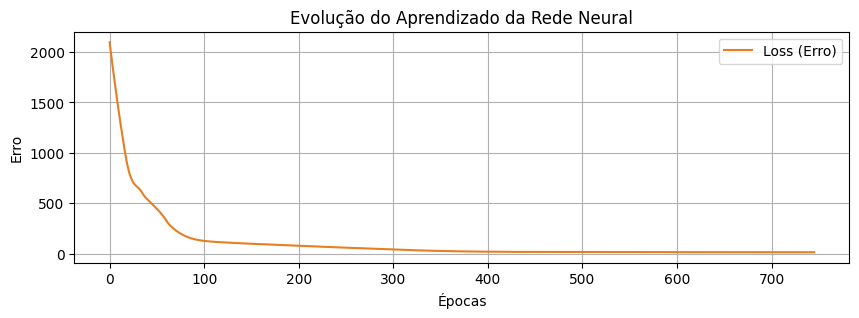

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import google.generativeai as genai
import matplotlib.pyplot as plt
import ipywidgets as widgets
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from IPython.display import display, clear_output

%matplotlib inline

# =================================================================
# 1. MOTOR FUZZY (Lógica da Etapa 2)
# =================================================================
distancia = ctrl.Antecedent(np.arange(0, 51, 1), 'distancia')
velocidade = ctrl.Antecedent(np.arange(0, 6, 1), 'velocidade')
prioridade = ctrl.Antecedent(np.arange(1, 11, 1), 'prioridade')
urgencia = ctrl.Consequent(np.arange(0, 101, 1), 'urgencia')

distancia.automf(3, names=['perto', 'media', 'longe'])
velocidade.automf(2, names=['baixa', 'alta'])
prioridade.automf(2, names=['baixa', 'alta'])
urgencia.automf(3, names=['baixa', 'media', 'alta'])

r1 = ctrl.Rule(distancia['perto'] | velocidade['alta'], urgencia['alta'])
r2 = ctrl.Rule(distancia['media'] & prioridade['alta'], urgencia['alta'])
r3 = ctrl.Rule(distancia['media'] & prioridade['baixa'], urgencia['media'])
r4 = ctrl.Rule(distancia['longe'] & velocidade['baixa'], urgencia['baixa'])
sim_fuzzy = ctrl.ControlSystemSimulation(ctrl.ControlSystem([r1, r2, r3, r4]))

# =================================================================
# 2. ETAPA 3: REDE NEURAL (IA Preditiva)
# =================================================================
print("🧠 Treinando a Rede Neural para a Etapa 3... (Aguarde uns 5 segundos)")

X, y = [], []
for _ in range(1500):
    d, v, p = np.random.uniform(0, 50), np.random.uniform(0, 5), np.random.randint(1, 11)
    try:
        sim_fuzzy.input['distancia'] = d
        sim_fuzzy.input['velocidade'] = v
        sim_fuzzy.input['prioridade'] = p
        sim_fuzzy.compute()
        X.append([d, v, p]); y.append(sim_fuzzy.output['urgencia'])
    except: continue

X_train, X_test, y_train, y_test = train_test_split(np.array(X), np.array(y), test_size=0.2)

rna = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)
rna.fit(X_train, y_train)

plt.figure(figsize=(10, 3))
plt.plot(rna.loss_curve_, color='#e67e22', label='Loss (Erro)')
plt.title('Evolução do Aprendizado da Rede Neural')
plt.xlabel('Épocas'); plt.ylabel('Erro'); plt.legend(); plt.grid(True)
plt.show()

# =================================================================
# 3. DASHBOARD FINAL INTEGRADO
# =================================================================
dist_slider = widgets.IntSlider(value=15, min=0, max=50, description='Distância')
vel_slider = widgets.FloatSlider(value=4.0, min=0, max=5, step=0.1, description='Velocidade')
prio_slider = widgets.IntSlider(value=5, min=1, max=10, description='Prioridade')
btn_ia = widgets.Button(description='Análise Gemini (Etapa 3)', button_style='warning')
out_dashboard = widgets.Output(); out_txt = widgets.Output()

def atualizar(dist, vel, prio):
    with out_dashboard:
        clear_output(wait=True)
        val_rna = np.clip(rna.predict([[dist, vel, prio]])[0], 0, 100)

        sim_fuzzy.input['distancia'] = dist
        sim_fuzzy.input['velocidade'] = vel
        sim_fuzzy.input['prioridade'] = prio
        sim_fuzzy.compute()
        val_fuzzy = sim_fuzzy.output['urgencia']

        fig, ax = plt.subplots(1, 2, figsize=(12, 3))
        ax[0].bar(['Fuzzy (Manual)', 'RNA (Aprendida)'], [val_fuzzy, val_rna], color=['#bdc3c7', '#d35400'])
        ax[0].set_ylim(0, 100); ax[0].set_title("Comparação de Modelos")

        cor = '#2ecc71' if val_rna < 40 else ('#f1c40f' if val_rna < 70 else '#e74c3c')
        ax[1].add_patch(plt.Circle((0.5, 0.5), 0.3, color=cor))
        ax[1].text(0.5, 0.5, f"{val_rna:.1f}%", ha='center', va='center', color='white', fontsize=12)
        ax[1].set_axis_off(); ax[1].set_title("Status Preditivo (RNA)")
        plt.show()

def chamar_gemini(b):
    with out_txt:
        clear_output()
        print("⏳ Autenticando e buscando modelos disponíveis na sua chave...")

        # ---> COLE SUA CHAVE NOVA AQUI DENTRO DAS ASPAS <---
        # Por favor, não mande a chave aqui no chat de novo por segurança!
        CHAVE_API = "SUA_CHAVE_AQUI"
        genai.configure(api_key=CHAVE_API)

        res_rna = rna.predict([[dist_slider.value, vel_slider.value, prio_slider.value]])[0]
        prompt = f"Analise o aprendizado do AGV: Sensores [D:{dist_slider.value}, V:{vel_slider.value}, P:{prio_slider.value}]. Urgência predita pela Rede Neural: {res_rna:.2f}%. Explique como a RNA aprendeu a prever esse risco de forma diferente da lógica manual."

        try:
            # Pega automaticamente o melhor modelo que a SUA chave tem acesso
            modelos_disponiveis = [m.name for m in genai.list_models() if 'generateContent' in m.supported_generation_methods]

            if not modelos_disponiveis:
                print("❌ Sua chave conectou, mas o Google não liberou nenhum modelo de texto para ela.")
                return

            # Escolhe o modelo mais avançado disponível (prioriza o flash)
            modelo_escolhido = next((m for m in modelos_disponiveis if 'flash' in m), modelos_disponiveis[0])
            print(f"✅ Conectado com sucesso! Usando o modelo: {modelo_escolhido}\n")

            # Gera o conteúdo
            model = genai.GenerativeModel(modelo_escolhido)
            r = model.generate_content(prompt)
            print("-" * 30 + "\nRELATÓRIO ETAPA 3\n" + "-" * 30 + f"\n{r.text}")

        except Exception as e:
            print(f"❌ ERRO REAL DA API: {e}\n(Verifique se a chave foi colada corretamente).")

btn_ia.on_click(chamar_gemini)
display(widgets.VBox([
    widgets.HBox([dist_slider, vel_slider, prio_slider]),
    widgets.interactive_output(atualizar, {'dist': dist_slider, 'vel': vel_slider, 'prio': prio_slider}),
    out_dashboard, btn_ia, out_txt
]))